# The Experiment
This file will walk you through how the data is presented. This will be used to make clear on how the image data would be viewed by python and will be used as a guide to further create the software dirver for the Custom IP.

In [1]:
import numpy as np
from PIL import Image
import pandas as pd
from IPython.display import display
from scipy.signal import convolve2d
import matplotlib.pyplot as plt


## Example With Greyscale Image
Below we will walk through step by step on openig an image and we will print the matrix to see how that looks like. 

### Printing the image

Width: 28, Height: 28


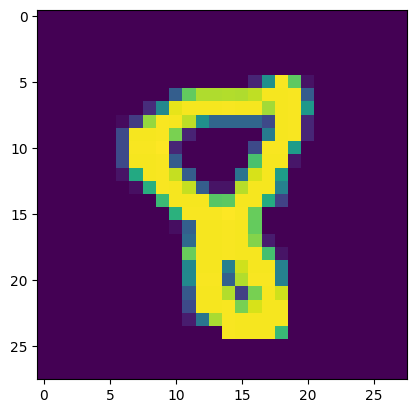

In [2]:
# 1. Open the image file
img = Image.open('8.png')

# 2. Extract dimensions using the .size property
width, height = img.size
print(f"Width: {width}, Height: {height}")

# 3. Display the image using Matplotlib
plt.imshow(img)

# plt.axis('off') # Optional: hides the axis rulers
plt.show()

### Observing the Complete Matrix of the Image
If observed the matrix of the greyscale image also refelcts the image in a ASCII art form. The data ranges form 0-255 max. Which means we can stic with 8bits of data. we can made design decision from here that. 
- Design can be of 8 bit
- Design can support subtraction by using 2'scompliment at frimware level for 5-1 we can do 5 + 255
- The matrix also represents the same image we see above

In [3]:
# 4. Convert to NumPy Array (int32 for math safety)
matrix = np.array(img, dtype=np.int32) 

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

#5. Printing the matrix 
display(pd.DataFrame(matrix))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26,128,253,192,12,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,76,194,225,225,226,225,231,252,252,253,74,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,32,120,246,252,252,252,253,252,252,220,252,253,136,0,0,0,0,0,0,0
8,0,0,0,0,0,0,7,44,215,253,252,230,129,84,84,84,84,56,252,253,27,0,0,0,0,0,0,0
9,0,0,0,0,0,0,57,252,252,253,204,25,0,0,0,0,0,107,252,253,27,0,0,0,0,0,0,0


In [8]:
kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])
 
result = convolve2d(matrix, kernel, mode='valid')
 
# 7. Clamp to [0, 255]
result_clamped = np.clip(result, 0, 255).astype(np.uint8)
 
# 8. Print output matrix
print(f"\nOutput shape: {result_clamped.shape}")
print("\nConvolved & Clamped Matrix:")
print(pd.DataFrame(result_clamped))
 


 



Output shape: (26, 26)

Convolved & Clamped Matrix:
    0   1   2   3   4   5   6   7    8    9    10   11   12   13   14   15   16   17   18   19   20  21  22  23  24  25
0    0   0   0   0   0   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0    0   0   0   0   0   0
1    0   0   0   0   0   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0    0   0   0   0   0   0
2    0   0   0   0   0   0   0   0    0    0    0    0    0    0    0    0    0    0    0    0    0   0   0   0   0   0
3    0   0   0   0   0   0   0   0    0    0    0    0    0    0    0    0    0    0  241  192   12   0   0   0   0   0
4    0   0   0   0   0   0   0   0    0    0    0    0    0    0    0    0    0    0  255  255   98   0   0   0   0   0
5    0   0   0   0   0   0   0   0    0    0    0    0    0    0    0    0    0    0  255  255  255   0   0   0   0   0
6    0   0   0   0   0   0   0   0    0    0    0  115   42    0    0   65    0    0  255  255  255   0   0

Text(0.5, 1.0, 'Convolved (Sobel-X, clamped)')

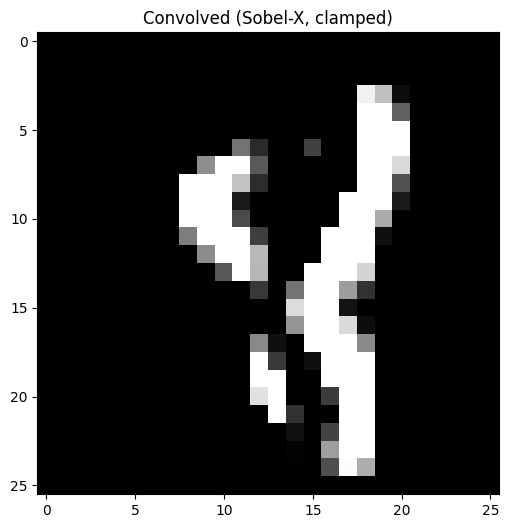

In [9]:
# 9. Display convolved image
plt.figure(figsize=(6, 6))
plt.imshow(result_clamped, cmap='gray', vmin=0, vmax=255)
plt.title('Convolved (Sobel-X, clamped)')